### Set up

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.svm import SVR
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers

In [2]:
df = pd.read_csv('c13k_selections.csv')

with open("c13k_problems.json") as f:
    problems = json.load(f)

### Feature Engineering

In [3]:
EV_A, EV_B = [], []
Var_A, Var_B = [], []
Skew_A, Skew_B = [], []
Max_A, Max_B = [], []
Min_A, Min_B = [], []

for i in range(len(df)):
    prob = problems[str(i)]

    # Gamble A
    pA, xA = zip(*prob["A"])
    pA = np.array(pA)
    xA = np.array(xA)

    ev_a = np.sum(pA * xA)
    var_a = np.sum(pA * (xA - ev_a)**2)
    skew_a = np.sum(pA * (xA - ev_a)**3) / (var_a**1.5 + 1e-6)

    EV_A.append(ev_a)
    Var_A.append(var_a)
    Skew_A.append(skew_a)
    Max_A.append(np.max(xA))
    Min_A.append(np.min(xA))

    # Gamble B
    pB, xB = zip(*prob["B"])
    pB = np.array(pB)
    xB = np.array(xB)

    ev_b = np.sum(pB * xB)
    var_b = np.sum(pB * (xB - ev_b)**2)
    skew_b = np.sum(pB * (xB - ev_b)**3) / (var_b**1.5 + 1e-6)

    EV_B.append(ev_b)
    Var_B.append(var_b)
    Skew_B.append(skew_b)
    Max_B.append(np.max(xB))
    Min_B.append(np.min(xB))

# Add to dataframe
df["EV_A"] = EV_A
df["Var_A"] = Var_A
df["Skew_A"] = Skew_A
df["Max_A"] = Max_A
df["Min_A"] = Min_A

df["EV_B"] = EV_B
df["Var_B"] = Var_B
df["Skew_B"] = Skew_B
df["Max_B"] = Max_B
df["Min_B"] = Min_B

# Differences (interactions)
df["EV_diff"] = df["EV_B"] - df["EV_A"]
df["Var_diff"] = df["Var_B"] - df["Var_A"]
df["Skew_diff"] = df["Skew_B"] - df["Skew_A"]
df["Max_diff"] = df["Max_B"] - df["Max_A"]
df["Min_diff"] = df["Min_B"] - df["Min_A"]

# Optional additional interactions
df["EV_x_Amb"] = df["EV_diff"] * df["Amb"]
df["Skew_x_feedback"] = df["Skew_diff"] * df["Feedback"]

### Prep data

In [4]:
y = df["bRate"].values
sample_weight = df["n"].values

X = df.drop(columns=["Problem", "bRate",])

categorical_cols = ["LotShapeB", "Block"]

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True) # one-hot encode categorical features

In [5]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weight, test_size=0.2, random_state=42
)

scaler = StandardScaler()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

### Decision Tree Model

In [6]:
dt = DecisionTreeRegressor(random_state=42)

dt_param_grid = [
  {'max_depth': list(range(1, 11))},
  {'min_samples_split': [2, 5, 10]},
  {'min_samples_leaf': [1, 2, 4]},
  {"max_features": [None, "sqrt", "log2"]}
 ]

dt_grid = GridSearchCV(dt, dt_param_grid, cv=cv)

dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_depth': [1, 2, ...]}, {'min_samples_split': [2, 5, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [8]:
best_dt = dt_grid.best_estimator_
print("Decision Tree best params:", dt_grid.best_params_)

Decision Tree best params: {'max_depth': 8}


In [9]:
predicted = best_dt.predict(X_test)

mae = mean_absolute_error(y_test, predicted)
r2 = r2_score(y_test, predicted)
rmse = np.sqrt(mean_squared_error(y_test, predicted))

print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.0823
Test R²: 0.7308
Test RMSE: 0.1148


In [10]:
importances = best_dt.feature_importances_


indices = np.argsort(importances)[::-1]

for f in range(X.shape[1]):
    print(f"{f+1}. feature {indices[f]} "
          f"{X.columns[indices[f]]} "
          f"{importances[indices[f]]}")

1. feature 22 EV_diff 0.4297602153582974
2. feature 11 bRate_std 0.27528817393043326
3. feature 26 Min_diff 0.062367352194477144
4. feature 25 Max_diff 0.030522481923049335
5. feature 12 EV_A 0.024006440462752788
6. feature 27 EV_x_Amb 0.023643655579824122
7. feature 23 Var_diff 0.02277811955146358
8. feature 16 Min_A 0.02072169447030734
9. feature 20 Max_B 0.020279163662802892
10. feature 13 Var_A 0.013705307985721928
11. feature 21 Min_B 0.012043308461683307
12. feature 5 Hb 0.010486464028254715
13. feature 18 Var_B 0.00958403301019562
14. feature 8 LotNumB 0.00950996309528961
15. feature 9 Amb 0.006376624960991042
16. feature 19 Skew_B 0.005723718300184131
17. feature 24 Skew_diff 0.005211393533550772
18. feature 2 Ha 0.004201848006049279
19. feature 4 La 0.003874313165703119
20. feature 15 Max_A 0.0018473918257960501
21. feature 17 EV_B 0.0018356495648432906
22. feature 7 Lb 0.001476007614972811
23. feature 3 pHa 0.0010178437582889846
24. feature 14 Skew_A 0.0007984758105519901
25.

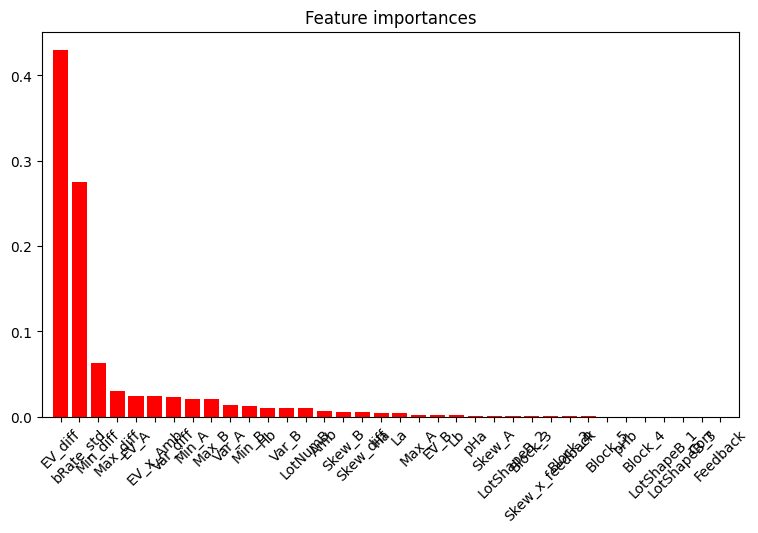

In [11]:
# Plot the feature importances
plt.figure(figsize=(9, 5))
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices],
        tick_label=[X.columns[x] for x in indices],
        color="r", align="center")
plt.xlim([-1, X.shape[1]])
_ = plt.xticks(rotation=45)

### Random Forest Reg model

In [12]:
rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    "n_estimators": list(range(70, 120)),
    'max_depth': list(range(1, 12)),
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = RandomizedSearchCV(
    rf,
    param_distributions=rf_param_grid,
    n_iter=30,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [70, 71, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

In [13]:
best_rf = rf_grid.best_estimator_
print("Random Forest best params:", rf_grid.best_params_)

Random Forest best params: {'n_estimators': 92, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 11}


In [14]:
y_pred_rf = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.0703
Test R²: 0.8151
Test RMSE: 0.0951


### XGBoost model Grid

In [17]:
xgb_reg = xgb.XGBRegressor()


xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_reg,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the c

In [18]:
best_xgb = xgb_grid.best_estimator_
print("XGBoost best params:", xgb_grid.best_params_)

XGBoost best params: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}


In [19]:
y_pred_xgb = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.0642
Test R²: 0.8427
Test RMSE: 0.0877


In [20]:
importances = best_xgb.feature_importances_

indices = np.argsort(importances)[::-1]

for f in range(X.shape[1]):
    print(f"{f+1}. feature {indices[f]} "
          f"{X.columns[indices[f]]} "
          f"{importances[indices[f]]}")

1. feature 22 EV_diff 0.24173520505428314
2. feature 11 bRate_std 0.10372700542211533
3. feature 9 Amb 0.0825277790427208
4. feature 26 Min_diff 0.05739318206906319
5. feature 25 Max_diff 0.04031411558389664
6. feature 12 EV_A 0.03379591926932335
7. feature 13 Var_A 0.03364386036992073
8. feature 4 La 0.03125390410423279
9. feature 23 Var_diff 0.02836156077682972
10. feature 18 Var_B 0.027680041268467903
11. feature 20 Max_B 0.027021747082471848
12. feature 27 EV_x_Amb 0.026315834373235703
13. feature 21 Min_B 0.02390596643090248
14. feature 19 Skew_B 0.023759454488754272
15. feature 8 LotNumB 0.02371317334473133
16. feature 30 LotShapeB_2 0.02266640029847622
17. feature 7 Lb 0.01986071839928627
18. feature 24 Skew_diff 0.01632271520793438
19. feature 5 Hb 0.015528563410043716
20. feature 6 pHb 0.012941846624016762
21. feature 3 pHa 0.012306503020226955
22. feature 29 LotShapeB_1 0.01184899266809225
23. feature 14 Skew_A 0.010994793847203255
24. feature 17 EV_B 0.009978209622204304
25.

C:\Users\George\AppData\Local\Temp\ipykernel_10132\2082641327.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()  # automatically adjusts spacing


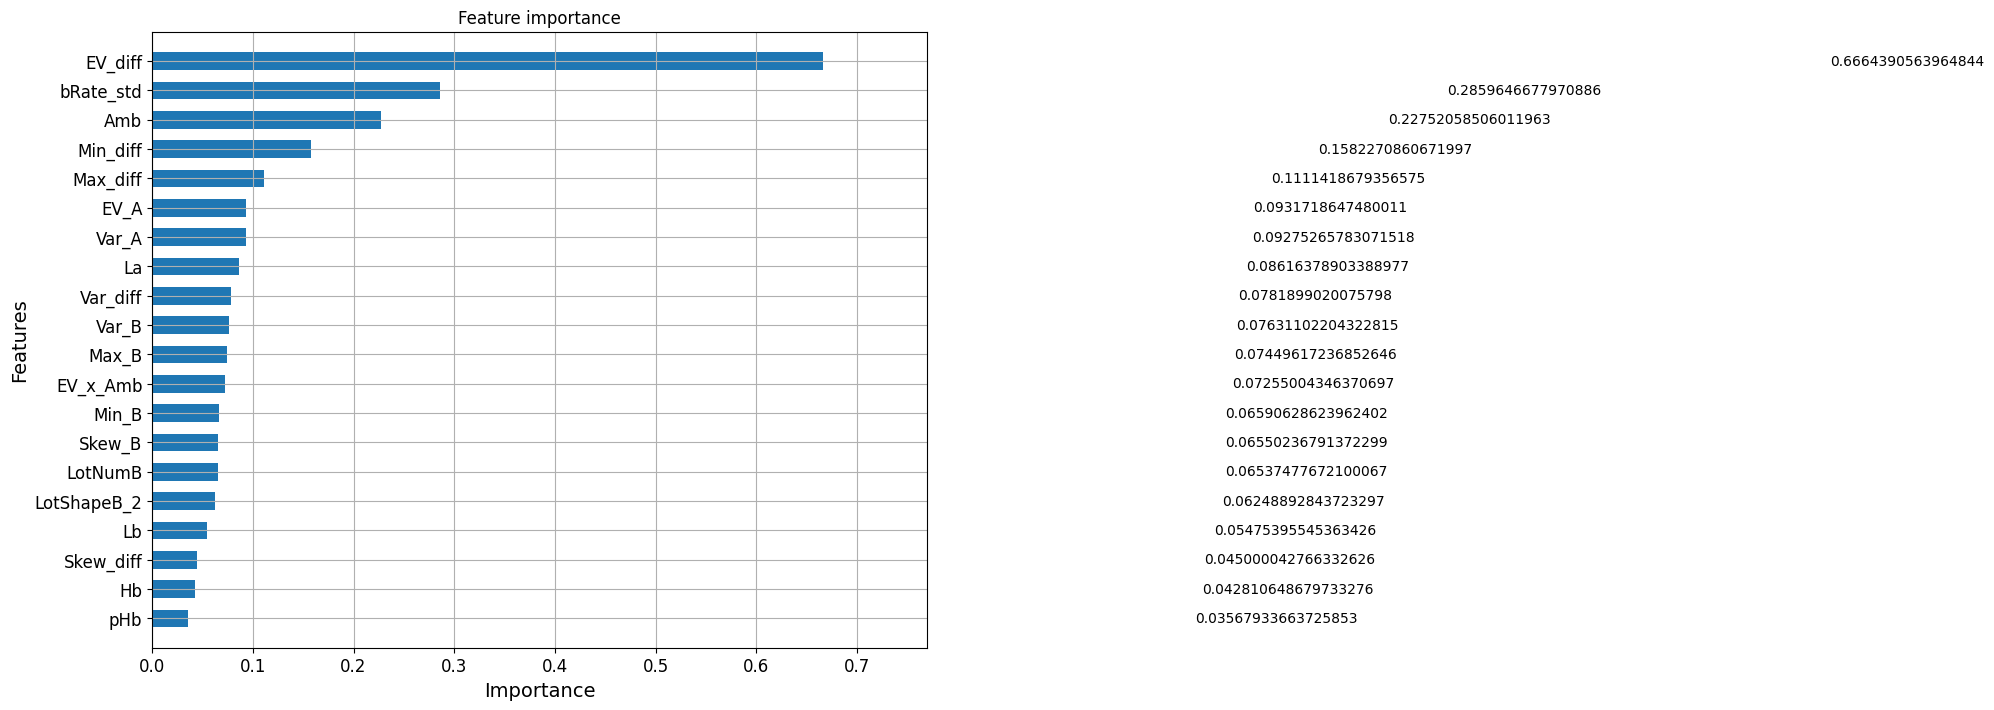

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
best_xgb.get_booster().feature_names = X.columns.to_list()
xgb.plot_importance(
    best_xgb.get_booster(),
    ax=fig.gca(),
    importance_type='gain',
    max_num_features=20,        # top 20
    height=0.6,                 # increase bar height for spacing
    show_values=True            # display importance values
)


current_xlim = ax.get_xlim()
ax.set_xlim(0, current_xlim[1]*1.05)  # small 5% padding instead of default huge space
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()  # automatically adjusts spacing

### XGBoost model random

In [22]:
xgb_reg = xgb.XGBRegressor(objective="reg:absoluteerror")

xgb_param_dist = {
    "n_estimators": list(range(80, 220)),
    'max_depth': list(range(1, 12)),
    "learning_rate": np.linspace(0.01, 0.1, 10),      # 10 values between 0.01 and 0.1
    "subsample": np.linspace(0.5, 1.0, 6),             # 6 values between 0.5 and 1.0
    "colsample_bytree": np.linspace(0.6, 1.0, 5),
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.05, 0.1, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 5, 10]
}

n_iter_search = 150
xgb_random = RandomizedSearchCV(
    xgb_reg,
    param_distributions=xgb_param_dist,
    n_iter=n_iter_search,
    cv=cv,
    scoring="neg_mean_absolute_error", #neg_mean_absolute_error
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': array([0.6, 0....8, 0.9, 1. ]), 'gamma': [0, 0.05, ...], 'learning_rate': array([0.01, ..., 0.09, 0.1 ]), 'max_depth': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross

In [23]:
best_xgb = xgb_random.best_estimator_
print("XGBoost best params:", xgb_random.best_params_)

XGBoost best params: {'subsample': np.float64(0.6), 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 166, 'min_child_weight': 7, 'max_depth': 10, 'learning_rate': np.float64(0.05000000000000001), 'gamma': 0.05, 'colsample_bytree': np.float64(0.8)}


In [24]:
y_pred_xgb = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.0655
Test R²: 0.8418
Test RMSE: 0.0880


In [25]:
importances = best_xgb.feature_importances_

indices = np.argsort(importances)[::-1]

for f in range(X.shape[1]):
    print(f"{f+1}. feature {indices[f]} "
          f"{X.columns[indices[f]]} "
          f"{importances[indices[f]]}")

1. feature 22 EV_diff 0.09777574986219406
2. feature 9 Amb 0.0454021617770195
3. feature 11 bRate_std 0.0449950210750103
4. feature 26 Min_diff 0.04449952393770218
5. feature 25 Max_diff 0.03342125192284584
6. feature 30 LotShapeB_2 0.03175253048539162
7. feature 13 Var_A 0.030305204913020134
8. feature 12 EV_A 0.029855018481612206
9. feature 27 EV_x_Amb 0.02949007786810398
10. feature 16 Min_A 0.028043868020176888
11. feature 21 Min_B 0.02795683965086937
12. feature 23 Var_diff 0.027895338833332062
13. feature 19 Skew_B 0.02656041644513607
14. feature 4 La 0.026443518698215485
15. feature 20 Max_B 0.02580077201128006
16. feature 14 Skew_A 0.025511447340250015
17. feature 8 LotNumB 0.025434115901589394
18. feature 18 Var_B 0.025144105777144432
19. feature 6 pHb 0.024251289665699005
20. feature 15 Max_A 0.023752769455313683
21. feature 3 pHa 0.02336033619940281
22. feature 24 Skew_diff 0.02305171824991703
23. feature 29 LotShapeB_1 0.022572889924049377
24. feature 7 Lb 0.022205363959074

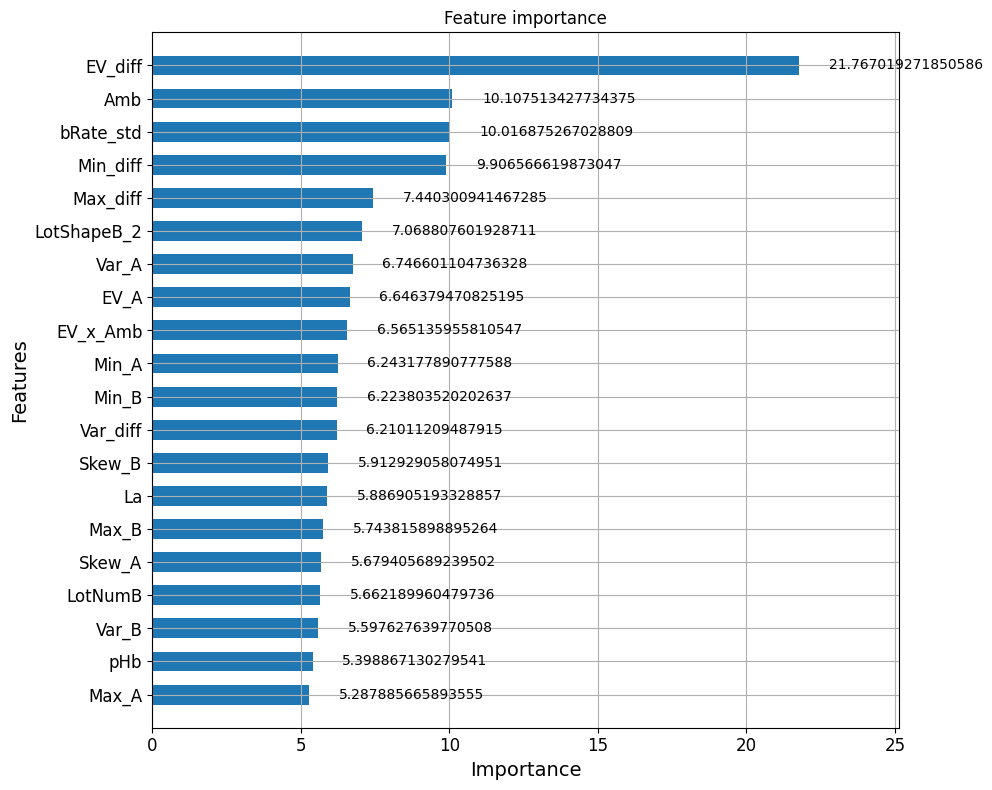

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
best_xgb.get_booster().feature_names = X.columns.to_list()
xgb.plot_importance(
    best_xgb.get_booster(),
    ax=fig.gca(),
    importance_type='gain',
    max_num_features=20,        # top 20
    height=0.6,                 # increase bar height for spacing
    show_values=True            # display importance values
)


current_xlim = ax.get_xlim()
ax.set_xlim(0, current_xlim[1]*1.05)  # small 5% padding instead of default huge space
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()  # automatically adjusts spacing

### Stohastic Gradient Desent model

In [27]:
sgd = make_pipeline(StandardScaler(), SGDRegressor(random_state=42))

sgd_param_grid = {
    "sgdregressor__loss": ["squared_error", "huber", "epsilon_insensitive"],
    "sgdregressor__penalty": ["l2", "l1", "elasticnet"],
    "sgdregressor__alpha": np.logspace(-5, -1, 10),  # regularization strength
    "sgdregressor__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "sgdregressor__eta0": [0.001, 0.01, 0.1]
}

sgd_random = GridSearchCV(
    sgd,
    param_grid=sgd_param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",  # since MAE is your priority
    n_jobs=-1
)

sgd_random.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'sgdregressor__alpha': array([1.0000...00000000e-01]), 'sgdregressor__eta0': [0.001, 0.01, ...], 'sgdregressor__learning_rate': ['constant', 'optimal', ...], 'sgdregressor__loss': ['squared_error', 'huber', ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... 

In [28]:
best_sgd = sgd_random.best_estimator_
print("SGD Regressor best params:", sgd_random.best_params_)

SGD Regressor best params: {'sgdregressor__alpha': np.float64(7.742636826811278e-05), 'sgdregressor__eta0': 0.1, 'sgdregressor__learning_rate': 'adaptive', 'sgdregressor__loss': 'huber', 'sgdregressor__penalty': 'elasticnet'}


In [29]:
y_pred_sgd = best_sgd.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_sgd)
r2 = r2_score(y_test, y_pred_sgd)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sgd))

print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.1263
Test R²: 0.4912
Test RMSE: 0.1578


### Elastic net Reg model

In [30]:
elastic = make_pipeline(StandardScaler(), ElasticNet(random_state=42))

param_dist = {
    "elasticnet__alpha": np.logspace(-4, 1, 20),   # Regularization strength
    "elasticnet__l1_ratio": np.linspace(0, 1, 11), # 0 = Ridge, 1 = Lasso
}

n_iter_search = 50

elastic_random = RandomizedSearchCV(
    elastic,
    param_distributions=param_dist,
    n_iter=n_iter_search,
    cv=cv,
    scoring="neg_mean_absolute_error",  # MAE priority
    n_jobs=-1,
    random_state=42
)

elastic_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'elasticnet__alpha': array([1.0000...00000000e+01]), 'elasticnet__l1_ratio': array([0. , 0....8, 0.9, 1. ])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [31]:
best_elastic = elastic_random.best_estimator_
print("Elastic Net best params:", elastic_random.best_params_)

Elastic Net best params: {'elasticnet__l1_ratio': np.float64(0.4), 'elasticnet__alpha': np.float64(0.00018329807108324357)}


In [32]:
y_pred = best_elastic.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.1268
Test R²: 0.4971
Test RMSE: 0.1569


### Support Vector Regression 

In [33]:
svr = make_pipeline(StandardScaler(), SVR(kernel="rbf"))

param_dist = {
    "svr__C": np.logspace(-2, 3, 10),      # Regularization strength
    "svr__gamma": ["scale", "auto"] + list(np.logspace(-3, 1, 10)),  # Kernel coefficient
    "svr__epsilon": np.logspace(-3, 0, 5)  # Tube width for regression
}

n_iter_search = 5

svr_random = RandomizedSearchCV(
    svr,
    param_distributions=param_dist,
    n_iter=n_iter_search,
    cv=cv,
    scoring="neg_mean_absolute_error",  # prioritize MAE
    n_jobs=-1,
    random_state=42
)

svr_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': array([1.0000...00000000e+03]), 'svr__epsilon': array([0.001 ..., 1. ]), 'svr__gamma': ['scale', 'auto', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [34]:
best_svr = svr_random.best_estimator_
print("SVR best params:", svr_random.best_params_)

SVR best params: {'svr__gamma': np.float64(0.0027825594022071257), 'svr__epsilon': np.float64(0.005623413251903491), 'svr__C': np.float64(77.42636826811278)}


In [35]:
y_pred = best_svr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.0889
Test R²: 0.7334
Test RMSE: 0.1143


### Extra Tree reg

In [36]:
et = ExtraTreesRegressor(random_state=42)

param_dist = {
    "n_estimators": list(range(50, 200, 10)),    # Number of trees
    "max_depth": [None] + list(range(3, 15)),   # Max depth of each tree
    "min_samples_split": [2, 5, 10],            # Min samples to split an internal node
    "min_samples_leaf": [1, 2, 4],              # Min samples at a leaf
    "max_features": ["auto", "sqrt", "log2"]    # Number of features to consider at split
}

n_iter_search = 50

et_random = RandomizedSearchCV(
    et,
    param_distributions=param_dist,
    n_iter=n_iter_search,
    cv=cv,
    scoring="neg_mean_absolute_error",  # prioritize MAE
    n_jobs=-1,
    random_state=42
)

et_random.fit(X_train, y_train)

C:\Users\George\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
90 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
51 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\George\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\George\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "C:\Users\George\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 492, in _validate_params
    va

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesReg...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategi

In [37]:
best_et = et_random.best_estimator_
print("Extra tree best params:", et_random.best_params_)

Extra tree best params: {'n_estimators': 140, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


In [38]:
y_pred = et_random.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.0809
Test R²: 0.7908
Test RMSE: 0.1012


### Neural Network Model

In [51]:
normalizer = layers.Normalization()
normalizer.adapt(X_train.to_numpy())

In [ ]:
def build_model(l2_strength=1e-4, dropout_rate=0.2, learning_rate=1e-3):

    model = models.Sequential([
        normalizer,
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2_strength)),
        layers.Dropout(float(dropout_rate)),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2_strength)),
        layers.Dropout(float(dropout_rate)),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(l2_strength)),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizers.Adam(float(learning_rate)),
        loss="mae", #binary_crossentropy #mse #mae
        metrics=["mae"]
    )

    return model

In [53]:
model = build_model()

# Train model
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.2215 - mae: 0.1333 - val_loss: 1.5002 - val_mae: 0.0895
Epoch 2/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6279 - mae: 0.0975 - val_loss: 1.3963 - val_mae: 0.0833
Epoch 3/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5192 - mae: 0.0910 - val_loss: 1.3171 - val_mae: 0.0785
Epoch 4/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4409 - mae: 0.0862 - val_loss: 1.2846 - val_mae: 0.0765
Epoch 5/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3949 - mae: 0.0834 - val_loss: 1.2554 - val_mae: 0.0748
Epoch 6/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3442 - mae: 0.0804 - val_loss: 1.2592 - val_mae: 0.0750
Epoch 7/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3308 - mae: 0.0796 - val_loss: 1.2216 - val_mae: 0.0727
Epoch 8/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3057 - mae: 0.0780 - val_loss: 1.2133 - val_mae: 0.0722
Epoch 9/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

In [54]:
test_loss, test_mae = model.evaluate(X_test, y_test, sample_weight=w_test)
print("Weighted Test MAE:", test_mae)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1491 - mae: 0.0684
Weighted Test MAE: 0.0683647021651268


In [55]:
y_pred = model.predict(X_test).flatten()

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [56]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

mae_list = []
rmse_list = []
r2_list = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{n_splits}")

    # Split data
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    w_train_fold, w_val_fold = sample_weight[train_idx], sample_weight[val_idx]

    # Build model
    model_cv = build_model()

    # Early stopping
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # Train model
    model_cv.fit(
        X_train_fold,
        y_train_fold,
        sample_weight=w_train_fold,
        validation_data=(X_val_fold, y_val_fold, w_val_fold),
        epochs=200,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    # Predictions
    y_pred_fold = model_cv.predict(X_val_fold).flatten()

    # Metrics (weighted)
    mae = np.average(np.abs(y_val_fold - y_pred_fold), weights=w_val_fold)
    rmse = np.sqrt(np.average((y_val_fold - y_pred_fold) ** 2, weights=w_val_fold))

    y_mean = np.average(y_val_fold, weights=w_val_fold)
    r2 = 1 - (
        np.sum(w_val_fold * (y_val_fold - y_pred_fold) ** 2) /
        np.sum(w_val_fold * (y_val_fold - y_mean) ** 2)
    )

    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)

    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}\n")

# ----- Average across folds -----
print("=== Cross-Validation Results ===")
print(f"Mean MAE: {np.mean(mae_list):.4f}")
print(f"Mean RMSE: {np.mean(rmse_list):.4f}")
print(f"Mean R²: {np.mean(r2_list):.4f}")

Fold 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MAE: 0.0645, RMSE: 0.0893, R²: 0.8343

Fold 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MAE: 0.0665, RMSE: 0.0904, R²: 0.8318

Fold 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MAE: 0.0634, RMSE: 0.0858, R²: 0.8516

Fold 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MAE: 0.0659, RMSE: 0.0889, R²: 0.8351

Fold 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MAE: 0.0651, RMSE: 0.0905, R²: 0.8247

=== Cross-Validation Results ===
Mean MAE: 0.0651
Mean RMSE: 0.0890
Mean R²: 0.8355


In [57]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 36)             │            73 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,390 (177.31 KB)

 Trainable params: 15,105 (59.00 KB)

 Non-trainable params: 73 (296.00 B)

 Optimizer params: 30,212 (118.02 KB)